In [1]:
import pandas as pd
import numpy as np

from matplotlib import pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_extraction import DictVectorizer
from sklearn.metrics import roc_auc_score
from sklearn.tree import export_text
from sklearn.ensemble import RandomForestClassifier

import xgboost as xgb


import time

%matplotlib inline

In [2]:
tree_auc = {}

In [3]:
# data = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-06-trees/CreditScoring.csv'
# !wget $data
# !mv CreditScoring.csv data/

In [4]:
df = pd.read_csv("data/CreditScoring.csv")

In [5]:
df.columns = df.columns.str.lower()

In [6]:
status_values = {
    1: 'ok',
    2: 'default',
    0: 'unk'
}

df.status = df.status.map(status_values)

home_values = {
    1: 'rent',
    2: 'owner',
    3: 'private',
    4: 'ignore',
    5: 'parents',
    6: 'other',
    0: 'unk'
}

df.home = df.home.map(home_values)

marital_values = {
    1: 'single',
    2: 'married',
    3: 'widow',
    4: 'separated',
    5: 'divorced',
    0: 'unk'
}

df.marital = df.marital.map(marital_values)

records_values = {
    1: 'no',
    2: 'yes',
    0: 'unk'
}

df.records = df.records.map(records_values)

job_values = {
    1: 'fixed',
    2: 'partime',
    3: 'freelance',
    4: 'others',
    0: 'unk'
}

df.job = df.job.map(job_values)

In [7]:
for c in ['income', 'assets', 'debt']:
    df[c] = df[c].replace(to_replace=99999999, value=np.nan)

In [8]:
# Removing the entry with an 'unknown' status

df = df[df.status != 'unk'].reset_index(drop=True)

In [9]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=11)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=11)

# Reset index
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

# Prepare target variable and drop it from the training dataset
y_train = (df_train.status == 'default').astype('int').values
y_val = (df_val.status == 'default').astype('int').values
y_test = (df_test.status == 'default').astype('int').values

del df_train['status']
del df_val['status']
del df_test['status']

In [10]:
train_dicts = df_train.fillna(0).to_dict(orient='records')

dv = DictVectorizer(sparse=False)
X_train = dv.fit_transform(train_dicts)

dt = DecisionTreeClassifier()# DECISION_TREE
dt.fit(X_train, y_train)

val_dicts = df_val.fillna(0).to_dict(orient='records')
X_val = dv.transform(val_dicts)

y_pred = dt.predict_proba(X_val)[:, 1]
roc_auc_score(y_val, y_pred)

0.658154924802015

In [11]:
# test for overfitting
'''
    AUC of 1.0 on training but 0.65 on validation: the tree memorized the training data. It learned one specific rule per customer,
    so on the customers it has seen it's perfect - but these rules don't generalize to unseen customers.
    This is overfitting: memorizing the data but failing to generalize.
'''

y_pred = dt.predict_proba(X_train)[:, 1]
roc_auc_score(y_train, y_pred)

1.0

In [12]:
# Tackling overfitting
dt = DecisionTreeClassifier(max_depth=2) # Added max_depth to prevent the tree from memorizing the data
dt.fit(X_train, y_train)

y_pred = dt.predict_proba(X_train)[:, 1]
auc = roc_auc_score(y_train, y_pred)
print('train:', auc)

y_pred = dt.predict_proba(X_val)[:, 1]
auc = roc_auc_score(y_val, y_pred)
print('val:', auc)

train: 0.7054989859726213
val: 0.6685264343319367


In [13]:
'''Looking inside the tree'''
# To see the rules the tree learned, we use export_text:

print(export_text(dt, feature_names=list(dv.get_feature_names_out())))

|--- records=yes <= 0.50
|   |--- job=partime <= 0.50
|   |   |--- class: 0
|   |--- job=partime >  0.50
|   |   |--- class: 1
|--- records=yes >  0.50
|   |--- seniority <= 6.50
|   |   |--- class: 1
|   |--- seniority >  6.50
|   |   |--- class: 0



   1 -> 0.606
   2 -> 0.669
   3 -> 0.739
   4 -> 0.761
   5 -> 0.766
   6 -> 0.762
  10 -> 0.678
  15 -> 0.671
  20 -> 0.667
None -> 0.657


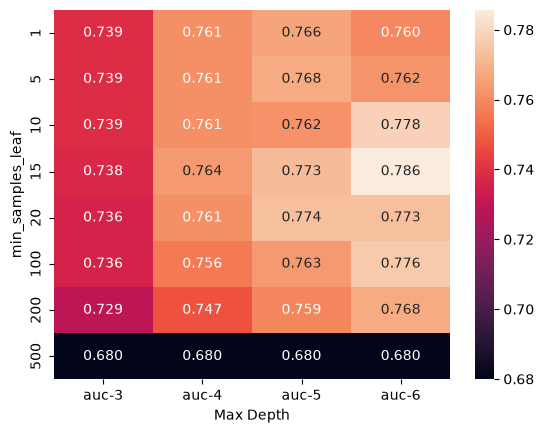

In [14]:
# Decision tree tuning.

# we start with max_depth
depths = [1, 2, 3, 4, 5, 6, 10, 15, 20, None]

for depth in depths:
    dt = DecisionTreeClassifier(max_depth=depth)
    dt.fit(X_train, y_train)

    y_pred = dt.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_pred)

    print('%4s -> %.3f' % (depth, auc))

# N.B Shallow trees underfit while deep trees overfit - and end up worse than shallow trees
promising_depths = [3, 4, 5, 6]


# We add min_leaf_samples  next after fininding promising tree depths
scores = []

for depth in promising_depths:
    for s in [1, 5, 10, 15, 20, 500, 100, 200]:
        dt = DecisionTreeClassifier(max_depth=depth, min_samples_leaf=s)
        dt.fit(X_train, y_train)

        y_pred = dt.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)

        scores.append((depth, s, auc))

# put the scores in a dataframe
columns = ['max_depth', 'min_samples_leaf', 'auc']
df_scores = pd.DataFrame(scores, columns=columns)

# The dataframe is hard to scan, hence why we pivot.
df_scores_pivot = df_scores.pivot(index='min_samples_leaf', columns=['max_depth'], values=['auc'])
df_scores_pivot.round(3)

df_scores_pivot
# dispaly the result in a heat map for better visualisation
sns.heatmap(df_scores_pivot, annot=True, fmt=".3f")
plt.xlabel("Max Depth")
plt.ylabel("min_samples_leaf")
plt.show()

# Form the heat map, we ascertain that the best combinations are max_depth=6, min_samples_leaf=15 which has an auc of 0.786

In [15]:
# Training final model
max_depth = 6
min_samples_leaf = 1

dt = DecisionTreeClassifier(max_depth=max_depth, min_samples_leaf=min_samples_leaf)
dt.fit(X_train, y_train)

print(export_text(dt, feature_names=list(dv.get_feature_names_out())))

auc = roc_auc_score(y_val, y_pred)
tree_auc['decision_tree'] = auc

|--- records=yes <= 0.50
|   |--- job=partime <= 0.50
|   |   |--- income <= 74.50
|   |   |   |--- assets <= 4250.00
|   |   |   |   |--- income <= 20.00
|   |   |   |   |   |--- seniority <= 1.50
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- seniority >  1.50
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |--- income >  20.00
|   |   |   |   |   |--- expenses <= 71.00
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- expenses >  71.00
|   |   |   |   |   |   |--- class: 1
|   |   |   |--- assets >  4250.00
|   |   |   |   |--- debt <= 1850.00
|   |   |   |   |   |--- age <= 22.50
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- age >  22.50
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |--- debt >  1850.00
|   |   |   |   |   |--- amount <= 1450.00
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- amount >  1450.00
|   |   |   |   |   |   |--- class: 0
|   |   |--- income >  74.50
|   |   |   |--- seniority <= 5.

Execution time for training Random Forest model: 6.523333 seconds


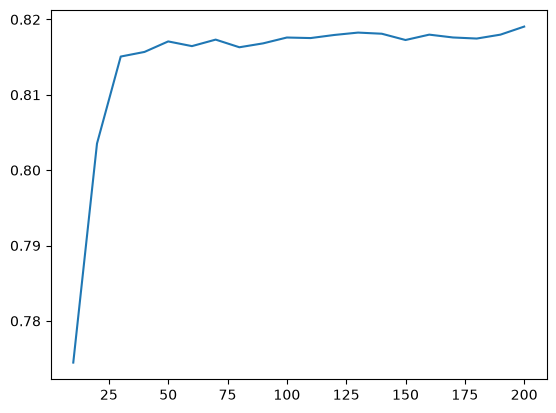

In [16]:
# Ensemble learning and random forest
scores = []

start_time = time.perf_counter()###########################################################
for n in range(10, 201, 10):
    rf = RandomForestClassifier(n_estimators=n, random_state=1)
    rf.fit(X_train, y_train)

    y_pred = rf.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_pred)

    scores.append((n, auc))

end_time = time.perf_counter()################################################################
execution_time = end_time - start_time########################################################
print(f"Execution time for training Random Forest model: {execution_time:.6f} seconds")###################

df_scores = pd.DataFrame(scores, columns=['n_estimators', 'auc'])
plt.plot(df_scores.n_estimators, df_scores.auc)

Execution time for training Random Forest model - with max_depth tuning: 16.721420 seconds


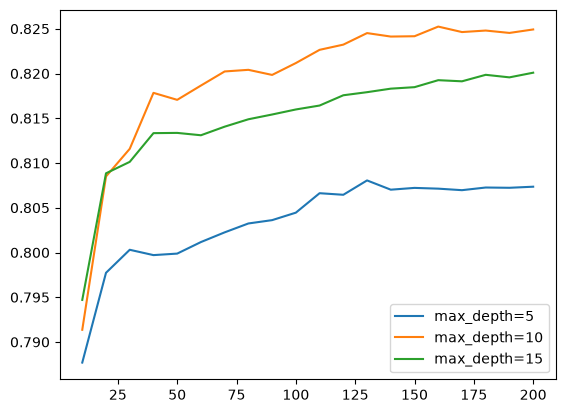

In [17]:
# tuning max_depth parameter
scores = []

start_time = time.perf_counter()###########################################################
for depth in [5, 10, 15]:
    for n in range(10, 201, 10):
        rf = RandomForestClassifier(n_estimators=n,
                                    max_depth=depth,
                                    random_state=1)
        rf.fit(X_train, y_train)

        y_pred = rf.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)

        scores.append((depth, n, auc))
end_time = time.perf_counter()################################################################
execution_time = end_time - start_time########################################################
print(f"Execution time for training Random Forest model - with max_depth tuning: {execution_time:.6f} seconds")###################
columns = ['max_depth', 'n_estimators', 'auc']
df_scores = pd.DataFrame(scores, columns=columns)

for d in [5, 10, 15]:
    df_subset = df_scores[df_scores.max_depth == d]

    plt.plot(df_subset.n_estimators, df_subset.auc,
             label='max_depth=%d' % d)

plt.legend()

Execution time for training the final Random Forest model: 26.242653 seconds


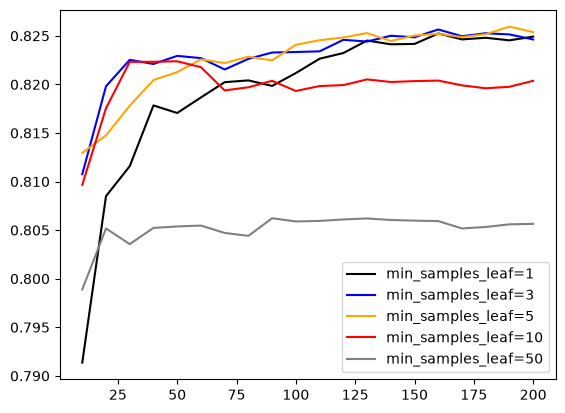

In [18]:
# tuning min_samples_leaf
max_depth = 10

scores = []

start_time = time.perf_counter()###########################################################
for s in [1, 3, 5, 10, 50]:
    for n in range(10, 201, 10):
        rf = RandomForestClassifier(n_estimators=n,
                                    max_depth=max_depth,
                                    min_samples_leaf=s,
                                    random_state=1)
        rf.fit(X_train, y_train)

        y_pred = rf.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)

        scores.append((s, n, auc))
end_time = time.perf_counter()################################################################
execution_time = end_time - start_time########################################################
print(f"Execution time for training the final Random Forest model: {execution_time:.6f} seconds")###################
columns = ['min_samples_leaf', 'n_estimators', 'auc']
df_scores = pd.DataFrame(scores, columns=columns)

colors = ['black', 'blue', 'orange', 'red', 'grey']
values = [1, 3, 5, 10, 50]

for s, col in zip(values, colors):
    df_subset = df_scores[df_scores.min_samples_leaf == s]

    plt.plot(df_subset.n_estimators, df_subset.auc,
             color=col,
             label='min_samples_leaf=%d' % s)

plt.legend()

min_samples_leaf = 3


In [19]:
# Training the final model
rf = RandomForestClassifier(n_estimators=200,
                            max_depth=max_depth,
                            min_samples_leaf=min_samples_leaf,
                            random_state=1)
rf.fit(X_train, y_train)
auc = roc_auc_score(y_val, y_pred)
tree_auc['random_forest'] = auc

In [20]:
# Gradient boosting and XGBoost

# Wrapping the data into DMatrix. This is because XGBoost does not work with numpy arrays
# It works with a special data structure called "DMatrix" which is optimised for training xgboost models

features = list(dv.get_feature_names_out())
dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=features)
dval = xgb.DMatrix(X_val, label=y_val, feature_names=features)

In [21]:
# %%capture output
# watchlist = [(dtrain, 'train'), (dval, 'val')]
# xgb_params = {
#     'eta': 0.3,
#     'max_depth': 6,
#     'min_child_weight': 1,

#     'objective': 'binary:logistic',
#     'eval_metric': 'auc',

#     'nthread': 8,
#     'seed': 1,
#     'verbosity': 1,
# }

# model = xgb.train(xgb_params, dtrain, num_boost_round=200,
#                   verbose_eval=5,
#                   evals=watchlist)

In [22]:
# def parse_xgb_output(output):
#     results = []

#     for line in output.stdout.strip().split('\n'):
#         it_line, train_line, val_line = line.split('\t')

#         it = int(it_line.strip('[]'))
#         train = float(train_line.split(':')[1])
#         val = float(val_line.split(':')[1])

#         results.append((it, train, val))

#     columns = ['num_iter', 'train_auc', 'val_auc']
#     df_results = pd.DataFrame(results, columns=columns)
#     return df_results

In [23]:
# df_score = parse_xgb_output(output)

# plt.plot(df_score.num_iter, df_score.train_auc, label='train')
# plt.plot(df_score.num_iter, df_score.val_auc, label='val')
# plt.legend()

In [24]:
watchlist = [(dtrain, 'train'), (dval, 'val')]  # list to store training and validation data
                                                # to evaluate the performance of the model after each training iteration.

xgb_params = {
    'eta': 0.3,
    'max_depth': 6,
    'min_child_weight': 1,

    'objective': 'binary:logistic',
    'eval_metric': 'auc',

    'nthread': 8,
    'seed': 1,
    'verbosity': 1,
}


evals_result = {}# stores training results

# train the model
model = xgb.train(params=xgb_params,
                  dtrain=dtrain,
                  num_boost_round=200,
                  verbose_eval=5,
                  evals=watchlist,
                  # early_stopping_rounds=10, # prevent overfitting
                  evals_result=evals_result)


# N.B. The training logs show that training auc clocks 1.00 with a huge gap to validation. This is a classic example of overfitting

[0]	train-auc:0.86632	val-auc:0.77998
[5]	train-auc:0.93359	val-auc:0.81150
[10]	train-auc:0.95391	val-auc:0.82002
[15]	train-auc:0.97087	val-auc:0.82220
[20]	train-auc:0.97677	val-auc:0.82239
[25]	train-auc:0.98440	val-auc:0.82074
[30]	train-auc:0.98805	val-auc:0.82061
[35]	train-auc:0.99239	val-auc:0.81804
[40]	train-auc:0.99474	val-auc:0.81732
[45]	train-auc:0.99627	val-auc:0.81413
[50]	train-auc:0.99753	val-auc:0.81320
[55]	train-auc:0.99811	val-auc:0.81140
[60]	train-auc:0.99893	val-auc:0.80818
[65]	train-auc:0.99924	val-auc:0.80696
[70]	train-auc:0.99955	val-auc:0.80710
[75]	train-auc:0.99979	val-auc:0.80802
[80]	train-auc:0.99987	val-auc:0.80813
[85]	train-auc:0.99993	val-auc:0.80761
[90]	train-auc:0.99995	val-auc:0.80782
[95]	train-auc:0.99997	val-auc:0.80870
[100]	train-auc:0.99999	val-auc:0.80839
[105]	train-auc:1.00000	val-auc:0.80735
[110]	train-auc:1.00000	val-auc:0.80730
[115]	train-auc:1.00000	val-auc:0.80779
[120]	train-auc:1.00000	val-auc:0.80570
[125]	train-auc:1.0000

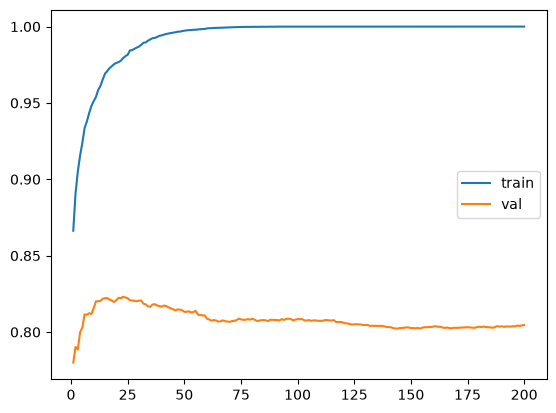

In [25]:
# OPTION-1: Displaying the graph after converting to a dataframe

# convert to a dataframe
columns = ['iter', 'train_auc', 'val_auc']
train_aucs = list(evals_result['train'].values())[0]
val_aucs = list(evals_result['val'].values())[0]

df_scores = pd.DataFrame(
    list(zip(
        range(1, len(train_aucs) + 1),
        train_aucs,
        val_aucs
    )), columns=columns)

plt.plot(df_scores.iter, df_scores.train_auc, label='train')
plt.plot(df_scores.iter, df_scores.val_auc, label='val')
plt.legend()

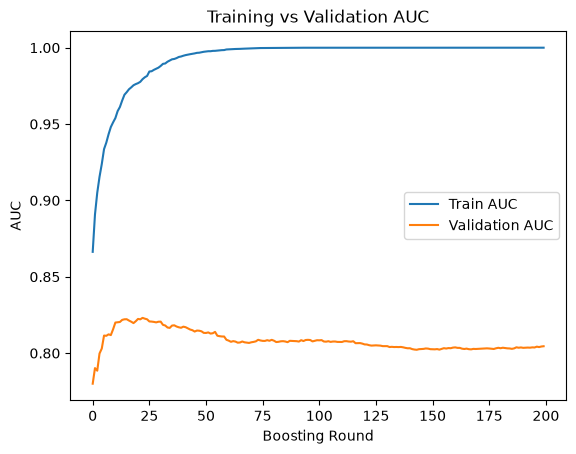

In [26]:
# OPTION-2: Displaying the graph without converting to a dataframe
plt.plot(evals_result['train']['auc'], label='Train AUC')
plt.plot(evals_result['val']['auc'], label='Validation AUC')

plt.xlabel('Boosting Round')
plt.ylabel('AUC')
plt.title('Training vs Validation AUC')
plt.legend()
plt.show()

[0]	train-auc:0.86632	val-auc:0.77998
[5]	train-auc:0.93359	val-auc:0.81150
[10]	train-auc:0.95391	val-auc:0.82002
[15]	train-auc:0.97087	val-auc:0.82220
[20]	train-auc:0.97677	val-auc:0.82239
[25]	train-auc:0.98440	val-auc:0.82074
[30]	train-auc:0.98805	val-auc:0.82061
[35]	train-auc:0.99239	val-auc:0.81804
[40]	train-auc:0.99474	val-auc:0.81732
[45]	train-auc:0.99627	val-auc:0.81413
[50]	train-auc:0.99753	val-auc:0.81320
[55]	train-auc:0.99811	val-auc:0.81140
[60]	train-auc:0.99893	val-auc:0.80818
[65]	train-auc:0.99924	val-auc:0.80696
[70]	train-auc:0.99955	val-auc:0.80710
[75]	train-auc:0.99979	val-auc:0.80802
[80]	train-auc:0.99987	val-auc:0.80813
[85]	train-auc:0.99993	val-auc:0.80761
[90]	train-auc:0.99995	val-auc:0.80782
[95]	train-auc:0.99997	val-auc:0.80870
[100]	train-auc:0.99999	val-auc:0.80839
[105]	train-auc:1.00000	val-auc:0.80735
[110]	train-auc:1.00000	val-auc:0.80730
[115]	train-auc:1.00000	val-auc:0.80779
[120]	train-auc:1.00000	val-auc:0.80570
[125]	train-auc:1.0000

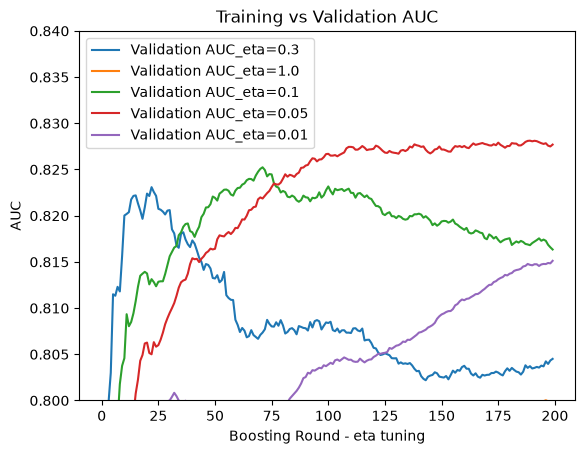

In [27]:
# XGBoosting: Tuning eta -learning rate.
watchlist = [(dtrain, 'train'), (dval, 'val')]
eta_params = [0.3, 1.0, 0.1, 0.05, 0.01]
output = {}

for eta in eta_params:
    xgb_params = {
        'eta': eta,
        'max_depth': 6,
        'min_child_weight': 1,
    
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
    
        'nthread': 8,
        'seed': 1,
        'verbosity': 1,
    }
    
    
    evals_result = {}# stores training results
    
    # train the model
    model = xgb.train(params=xgb_params,
                      dtrain=dtrain,
                      num_boost_round=200,
                      verbose_eval=5,
                      evals=watchlist,
                      # early_stopping_rounds=10, # prevent overfitting
                      evals_result=evals_result)
    key = f"eta={eta}"
    output[key] = evals_result

# Plot the outputs
for key, value in output.items():
    # plt.plot(value['train']['auc'], label=f'Train AUC_{key}')
    plt.plot(value['val']['auc'], label=f'Validation AUC_{key}')

plt.xlabel('Boosting Round - eta tuning')
plt.ylabel('AUC')

plt.ylim(0.8, 0.84) # We're interested in plots from 0.8 - 0.84

plt.title('Training vs Validation AUC')
plt.legend()
plt.show()

[0]	train-auc:0.86632	val-auc:0.77998
[5]	train-auc:0.90453	val-auc:0.79268
[10]	train-auc:0.92026	val-auc:0.80458
[15]	train-auc:0.92999	val-auc:0.81076
[20]	train-auc:0.93834	val-auc:0.81375
[25]	train-auc:0.94713	val-auc:0.81285
[30]	train-auc:0.95146	val-auc:0.81560
[35]	train-auc:0.95899	val-auc:0.81819
[40]	train-auc:0.96274	val-auc:0.81820
[45]	train-auc:0.96664	val-auc:0.82021
[50]	train-auc:0.96979	val-auc:0.82193
[55]	train-auc:0.97261	val-auc:0.82283
[60]	train-auc:0.97637	val-auc:0.82300
[65]	train-auc:0.97866	val-auc:0.82398
[70]	train-auc:0.98134	val-auc:0.82507
[75]	train-auc:0.98300	val-auc:0.82447
[80]	train-auc:0.98454	val-auc:0.82268
[85]	train-auc:0.98623	val-auc:0.82203
[90]	train-auc:0.98768	val-auc:0.82199
[95]	train-auc:0.98943	val-auc:0.82200
[100]	train-auc:0.99081	val-auc:0.82317
[105]	train-auc:0.99138	val-auc:0.82282
[110]	train-auc:0.99225	val-auc:0.82247
[115]	train-auc:0.99305	val-auc:0.82223
[120]	train-auc:0.99367	val-auc:0.82141
[125]	train-auc:0.9942

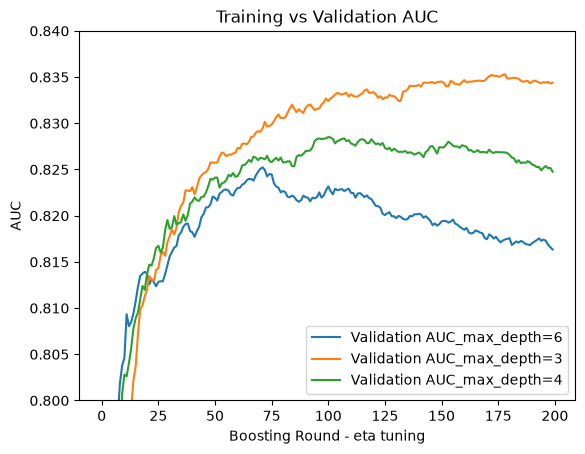

In [28]:
# XGBoosting: Tuning max_depth.

watchlist = [(dtrain, 'train'), (dval, 'val')]
best_eta = 0.1
depths = [6, 3, 4]
output = {}

for depth in depths:
    xgb_params = {
        'eta': best_eta,
        'max_depth': depth,
        'min_child_weight': 1,
    
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
    
        'nthread': 8,
        'seed': 1,
        'verbosity': 1,
    }
    
    
    evals_result = {}# stores training results
    
    # train the model
    model = xgb.train(params=xgb_params,
                      dtrain=dtrain,
                      num_boost_round=200,
                      verbose_eval=5,
                      evals=watchlist,
                      # early_stopping_rounds=10, # prevent overfitting
                      evals_result=evals_result)
    key = f"max_depth={depth}"
    output[key] = evals_result

# Plot the outputs
for key, value in output.items():
    # plt.plot(value['train']['auc'], label=f'Train AUC_{key}')
    plt.plot(value['val']['auc'], label=f'Validation AUC_{key}')

plt.xlabel('Boosting Round - eta tuning')
plt.ylabel('AUC')

plt.ylim(0.8, 0.84) # We're interested in plots from 0.8 - 0.84

plt.title('Training vs Validation AUC')
plt.legend()
plt.show()

[0]	train-auc:0.77610	val-auc:0.73891
[5]	train-auc:0.83148	val-auc:0.77512
[10]	train-auc:0.84959	val-auc:0.79036
[15]	train-auc:0.86042	val-auc:0.80374
[20]	train-auc:0.86923	val-auc:0.81200
[25]	train-auc:0.87551	val-auc:0.81434
[30]	train-auc:0.88150	val-auc:0.81779
[35]	train-auc:0.88589	val-auc:0.82108
[40]	train-auc:0.88999	val-auc:0.82309
[45]	train-auc:0.89370	val-auc:0.82460
[50]	train-auc:0.89730	val-auc:0.82573
[55]	train-auc:0.90073	val-auc:0.82642
[60]	train-auc:0.90342	val-auc:0.82734
[65]	train-auc:0.90582	val-auc:0.82800
[70]	train-auc:0.90811	val-auc:0.82908
[75]	train-auc:0.91057	val-auc:0.82988
[80]	train-auc:0.91225	val-auc:0.83058
[85]	train-auc:0.91457	val-auc:0.83155
[90]	train-auc:0.91632	val-auc:0.83169
[95]	train-auc:0.91797	val-auc:0.83157
[100]	train-auc:0.91970	val-auc:0.83241
[105]	train-auc:0.92157	val-auc:0.83318
[110]	train-auc:0.92274	val-auc:0.83314
[115]	train-auc:0.92405	val-auc:0.83322
[120]	train-auc:0.92535	val-auc:0.83337
[125]	train-auc:0.9271

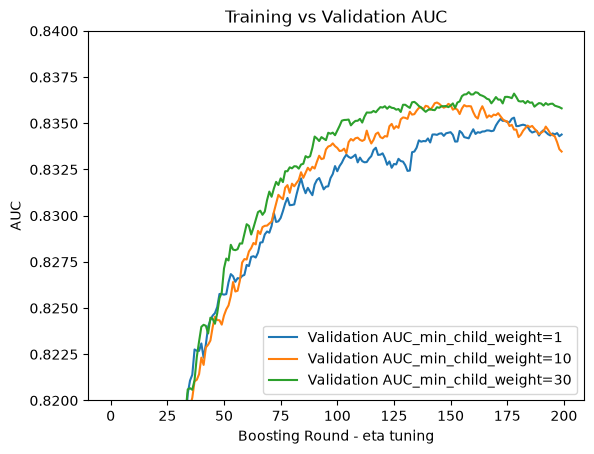

In [29]:
# XGBoosting: Tuning min_child_weight.

watchlist = [(dtrain, 'train'), (dval, 'val')]
best_eta = 0.1
best_depth = 3
min_child_weights = [1, 10, 30]
output = {}

for min_child_weight in min_child_weights:
    xgb_params = {
        'eta': best_eta,
        'max_depth': best_depth,
        'min_child_weight': min_child_weight,
    
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
    
        'nthread': 8,
        'seed': 1,
        'verbosity': 1,
    }
    
    
    evals_result = {}# stores training results
    
    # train the model
    model = xgb.train(params=xgb_params,
                      dtrain=dtrain,
                      num_boost_round=200,
                      verbose_eval=5,
                      evals=watchlist,
                      # early_stopping_rounds=10, # prevent overfitting
                      evals_result=evals_result)
    key = f"min_child_weight={min_child_weight}"
    output[key] = evals_result

# Plot the outputs
for key, value in output.items():
    # plt.plot(value['train']['auc'], label=f'Train AUC_{key}')
    plt.plot(value['val']['auc'], label=f'Validation AUC_{key}')

plt.xlabel('Boosting Round - eta tuning')
plt.ylabel('AUC')

plt.ylim(0.82, 0.84) # We're interested in plots from 0.82 - 0.84

plt.title('Training vs Validation AUC')
plt.legend()
plt.show()

[0]	train-auc:0.77610	val-auc:0.73891
[5]	train-auc:0.83148	val-auc:0.77512
[10]	train-auc:0.84959	val-auc:0.79036
[15]	train-auc:0.86042	val-auc:0.80374
[20]	train-auc:0.86923	val-auc:0.81200
[25]	train-auc:0.87551	val-auc:0.81434
[30]	train-auc:0.88150	val-auc:0.81779
[35]	train-auc:0.88589	val-auc:0.82108
[40]	train-auc:0.88999	val-auc:0.82309
[45]	train-auc:0.89370	val-auc:0.82460
[50]	train-auc:0.89730	val-auc:0.82573
[55]	train-auc:0.90073	val-auc:0.82642
[60]	train-auc:0.90342	val-auc:0.82734
[65]	train-auc:0.90582	val-auc:0.82800
[70]	train-auc:0.90811	val-auc:0.82908
[75]	train-auc:0.91057	val-auc:0.82988
[80]	train-auc:0.91225	val-auc:0.83058
[85]	train-auc:0.91457	val-auc:0.83155
[90]	train-auc:0.91632	val-auc:0.83169
[95]	train-auc:0.91797	val-auc:0.83157
[100]	train-auc:0.91970	val-auc:0.83241
[105]	train-auc:0.92157	val-auc:0.83318
[110]	train-auc:0.92274	val-auc:0.83314
[115]	train-auc:0.92405	val-auc:0.83322
[120]	train-auc:0.92535	val-auc:0.83337
[125]	train-auc:0.9271

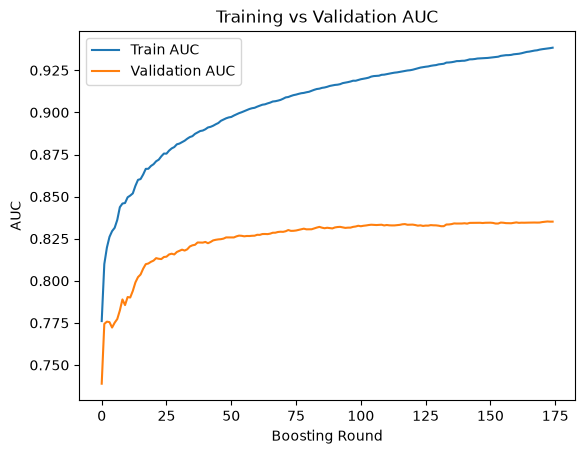

In [30]:
# Training the final model

eta = 0.1
max_depth = 3
min_child_weight = 1
num_boost_round = 175

watchlist = [(dtrain, 'train'), (dval, 'val')]
xgb_params = {
    'eta': eta,
    'max_depth': max_depth,
    'min_child_weight': min_child_weight,

    'objective': 'binary:logistic',
    'eval_metric': 'auc',

    'nthread': 8,
    'seed': 1,
    'verbosity': 1,
}


evals_result = {}# stores training results

# train the model
model = xgb.train(params=xgb_params,
                  dtrain=dtrain,
                  num_boost_round=num_boost_round,
                  verbose_eval=5,
                  evals=watchlist,
                  # early_stopping_rounds=10, # prevent overfitting
                  evals_result=evals_result)

y_pred = model.predict(dval)
auc = roc_auc_score(y_val, y_pred)
tree_auc['xgboost'] = auc

plt.plot(evals_result['train']['auc'], label='Train AUC')
plt.plot(evals_result['val']['auc'], label='Validation AUC')

plt.xlabel('Boosting Round')
plt.ylabel('AUC')
plt.title('Training vs Validation AUC')
plt.legend()
plt.show()

In [31]:
print(tree_auc)
max_key = max(tree_auc, key=tree_auc.get)
max_val = tree_auc[max_key]

max_val

{'decision_tree': 0.7682666924995762, 'random_forest': 0.8056446925480127, 'xgboost': 0.8351426460972124}


0.8351426460972124

In [32]:
# Time to train the final model. We have selected xGBoost as the best model because it has a hight auc of 0.835
# We now train the final XGBoost model on df_full_train dataset

df_full_train = df_full_train.reset_index(drop=True)
y_full_train = (df_full_train.status == 'default').astype(int).values
del df_full_train['status']


dicts_full_train = df_full_train.to_dict(orient='records')
dv = DictVectorizer(sparse=False)
X_full_train = dv.fit_transform(dicts_full_train)
dicts_test = df_test.to_dict(orient='records')
X_test = dv.transform(dicts_test)

features = list(dv.get_feature_names_out())
# print(features)

dfulltrain = xgb.DMatrix(X_full_train, label=y_full_train, feature_names=features)
dtest = xgb.DMatrix(X_test, feature_names=features)

xgb_params = {
    'eta': 0.1,
    'max_depth': 3,
    'min_child_weight': 1,

    'objective': 'binary:logistic',
    'eval_metric': 'auc',

    'nthread': 8,
    'seed': 1,
    'verbosity': 1,
}
model = xgb.train(xgb_params, dfulltrain, num_boost_round=175)

['age', 'amount', 'assets', 'debt', 'expenses', 'home=ignore', 'home=other', 'home=owner', 'home=parents', 'home=private', 'home=rent', 'home=unk', 'income', 'job=fixed', 'job=freelance', 'job=others', 'job=partime', 'job=unk', 'marital=divorced', 'marital=married', 'marital=separated', 'marital=single', 'marital=unk', 'marital=widow', 'price', 'records=no', 'records=yes', 'seniority', 'time']


In [33]:
y_pred = model.predict(dtest)
roc_auc_score(y_test, y_pred)

0.8290589414007137

In [ ]:
# Explore more


# There's a variation of random forest caled "extremely randomized trees", or "extra trees".
# Instead of selecting the best split among all possible thresholds, it selects a few thresholds randomly and picks the best one among them.
# Because of that extra trees never overfit.
# In Scikit-Learn, they are implemented in ExtraTreesClassifier.